# Домашнє завдання: ETL-пайплайни для аналітиків даних

Це ДЗ передбачене під виконання на локальній машині. Виконання з Google Colab буде суттєво ускладнене.

## Підготовка
1. Переконайтесь, що у вас встановлены необхідні бібліотеки:
   ```bash
   pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv
   ```

2. Створіть файл `.env` з параметрами підключення до бази даних classicmodels. Базу даних ви можете отримати через

  - docker-контейнер згідно існтрукції в [документі](https://www.notion.so/hannapylieva/Docker-1eb94835849480c9b2e7f5dc22ee4df9), також відео інструкції присутні на платформі - уроки "MySQL бази, клієнт для роботи з БД, Docker і ChatGPT для запитів" та "Як встановити Docker для роботи з базами даних без терміналу"
  - або встановивши локально цю БД - для цього перегляньте урок "Опціонально. Встановлення MySQL та  БД Сlassicmodels локально".
  
  Приклад `.env` файлу ми створювали в лекції. Ось його обовʼязкове наповнення:
    ```
    DB_HOST=your_host
    DB_PORT=3306 або 3307 - той, який Ви налаштували
    DB_USER=your_username
    DB_PASSWORD=your_password
    DB_NAME=classicmodels
    ```
  Якщо ви створили цей файл під час перегляду лекції - **новий створювати не треба**. Замініть лише назву БД, або пропишіть назву в коді створення підключення (замість отримання назви цільової БД зі змінних оточення). Але переконайтесь, що до `.env` файл лежить в тій самій папці, що і цей ноутбук.

  **УВАГА!** НЕ копіюйте скрит для **створення** `.env` файлу. В лекції він наводиться для прикладу. І давалось пояснення, що в реальних проєктах ми НІКОЛИ не пишемо доступи до бази в коді. Копіювання скрипта для створення `.env` файлу сюди в ДЗ буде вважатись грубою помилкою і ми зніматимемо бали.

3. Налаштуйте підключення через SQLAlchemy до БД за прикладом в лекції.

Рекомендую вивести (відобразити) змінну engine після створення. Вона має бути не None! Якщо None - значить у Вас не підтягнулись налаштування з .env файла.

Ви також можете налаштувати параметри підключення до БД без .env файла, просто прописавши текстом в відповідних місцях. Це - не рекомендований підхід.

## Підготовка :

In [1]:
# Перевіряємо встановленя необхідних бібліотек

!pip list | findstr "SQLAlchemy PyMySQL pandas matplotlib seaborn python-dotenv"

matplotlib                        3.10.6
matplotlib-inline                 0.2.1
pandas                            2.3.3
PyMySQL                           1.2.3
python-dotenv                     1.1.0
seaborn                           0.13.2
SQLAlchemy                        2.0.43


In [2]:
# Імпортуємо необхідні бібліотеки
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import datetime   

In [3]:
# Завантажуємо параметри підключення з файлу .env
load_dotenv(override=True)

True

In [4]:
# Створюємо підключення до БД через SQLAlchemy
def create_connection():
    host = os.getenv("DB_HOST")
    port = os.getenv("DB_PORT")
    user = os.getenv("DB_USER")
    password = os.getenv("DB_PASSWORD")
    database = os.getenv("DB_NAME")

    # Створюємо рядок підключення
    connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"

    # Створюємо engine
    engine = create_engine(
        connection_string,
        pool_size=2,
        max_overflow=20,
        pool_pre_ping=True,
        echo=False)

    # Перевіряємо підключення
    try:
        with engine.connect() as conn:
            conn.execute(text("SELECT 1"))

        print("Підключення до БД успішне!")
        print(f"Engine створено: {engine is not None}")

        return engine

    except Exception as e:
        print(f"Помилка підключення: {e}")
        return None


# Створюємо підключення
engine = create_connection()

Підключення до БД успішне!
Engine створено: True


In [5]:
# Перевіряємо, до якої бази даних виконано підключення
with engine.connect() as conn:
    result = conn.execute(text("SELECT DATABASE()"))
    print(result.scalar())

classicmodels


### Завдання 1: Створення таблиці курсів валют та API інтеграція (2 бали)

**Повторіть процедуру з лекції:** створіть таблицю для курсів валют, але вже в цій базі даних. Результатом має бути нова таблиця з курсами валют USD, EUR, UAH в БД (можна завантажити більше валют). Продемонструйте, що таблиця була додана, використовуючи SELECT.

Тобто тут ви можете прямо скопіювати код з лекції, внести необхідні зміни і запустити. Головне - отримати таблицю в БД classicmodels.

In [6]:
# Імпортуємо бібліотеку для роботи з API
import requests


In [13]:
# Створюємо таблицю для курсів валют
def create_currency_table(engine):
    """Створює таблицю через SQLAlchemy"""

    create_table_sql = text("""
    CREATE TABLE IF NOT EXISTS currency_rates (
        id INT AUTO_INCREMENT PRIMARY KEY,
        currency_code VARCHAR(3) NOT NULL,
        rate_to_usd DECIMAL(10, 6) NOT NULL,
        rate_date DATE NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
        INDEX idx_currency_date (currency_code, rate_date),
        UNIQUE KEY unique_currency_date (currency_code, rate_date)
    )
    """)

    with engine.connect() as conn:
        # Тут лише одна транзакція - conn.begin() не треба
        conn.execute(create_table_sql)

    print("✅ Таблиця currency_rates створена")


# Отримуємо курси валют з API
def fetch_exchange_rates():
    """Отримує курси валют з API"""

    try:
        # Безкоштовний API курсів валют
        url = "https://api.exchangerate-api.com/v4/latest/USD"

        # Відправляємо GET-запит до API
        response = requests.get(url, timeout=10)

        # Перевіряємо, чи запит виконано успішно
        response.raise_for_status()

        # Перетворюємо відповідь API з JSON у Python-словник
        data = response.json()

        # Валюти, які нас цікавлять
        # USD додано згідно з умовою домашнього завдання
        currencies = ['USD', 'EUR', 'GBP', 'UAH', 'PLN', 'JPY']

        # Створюємо порожній словник для курсів
        rates = {}

        # Записуємо потрібні курси валют у словник
        for currency in currencies:
            if currency in data['rates']:
                # Зберігаємо курс: скільки одиниць валюти за 1 USD
                rates[currency] = data['rates'][currency]

        # Повертаємо словник курсів та поточну дату
        return rates, datetime.date.today()

    except Exception as e:
        print(f"❌ Помилка API: {e}")
        return None, None


# Зберігаємо курси валют у базу даних
def save_exchange_rates(engine, rates_dict, rate_date):
    """Зберігає курси в БД з обробкою конфліктів"""

    # Перевіряємо, чи є дані для збереження
    if not rates_dict:
        print("❌ Немає даних для збереження")
        return False

    # SQL-запит з ON DUPLICATE KEY UPDATE для MySQL
    insert_sql = text("""
    INSERT INTO currency_rates (currency_code, rate_to_usd, rate_date)
    VALUES (:currency, :rate, :date)
    ON DUPLICATE KEY UPDATE
        rate_to_usd = VALUES(rate_to_usd),
        updated_at = CURRENT_TIMESTAMP
    """)

    try:
        # Відкриваємо підключення до БД
        with engine.connect() as conn:

            # Одна транзакція для всіх вставок
            with conn.begin():

                # Записуємо кожну валюту в таблицю
                for currency, rate in rates_dict.items():
                    conn.execute(
                        insert_sql,
                        {
                            'currency': currency,
                            'rate': rate,
                            'date': rate_date
                        }
                    )

        print(f"✅ Збережено {len(rates_dict)} курсів валют на {rate_date}")
        return True

    except Exception as e:
        print(f"❌ Помилка збереження: {e}")
        return False

In [14]:
# Виконуємо повний цикл API → БД

# Створюємо таблицю currency_rates
create_currency_table(engine)

print("📡 Отримуємо курси валют...")

# Отримуємо курси валют з API
rates, date = fetch_exchange_rates()

# Перевіряємо, чи курси успішно отримані
if rates:
    print(f"Отримані курси на {date}:")

    # Виводимо отримані курси валют
    for currency, rate in rates.items():
        print(f"  1 USD = {rate:.4f} {currency}")

    # Зберігаємо отримані курси в базу даних
    if save_exchange_rates(engine, rates, date):

        # Перевіряємо збережені дані через SELECT
        verification_df = pd.read_sql(
            "SELECT * FROM currency_rates ORDER BY created_at DESC LIMIT 10",
            engine
        )

        print("\nЗбережені дані:")
        display(verification_df)

✅ Таблиця currency_rates створена
📡 Отримуємо курси валют...
Отримані курси на 2026-09-25:
  1 USD = 1.0000 USD
  1 USD = 0.8790 EUR
  1 USD = 0.7560 GBP
  1 USD = 44.9500 UAH
  1 USD = 3.8500 PLN
  1 USD = 158.6900 JPY
✅ Збережено 6 курсів валют на 2026-09-25

Збережені дані:


,id,currency_code,rate_to_usd,rate_date,created_at,updated_at
0,1,USD,1.000,2026-09-25,2026-09-25 17:57:21,2026-09-25 17:57:21
1,2,EUR,0.879,2026-09-25,2026-09-25 17:57:21,2026-09-25 17:57:21
2,3,GBP,0.756,2026-09-25,2026-09-25 17:57:21,2026-09-25 17:57:21
3,4,UAH,44.950,2026-09-25,2026-09-25 17:57:21,2026-09-25 17:57:21
4,5,PLN,3.850,2026-09-25,2026-09-25 17:57:21,2026-09-25 17:57:21
5,6,JPY,158.690,2026-09-25,2026-09-25 17:57:21,2026-09-25 17:57:21


In [15]:
print("📡 Отримуємо курси валют...")
rates, date = fetch_exchange_rates()

if rates:
    print(f"Отримані курси на {date}:")
    for currency, rate in rates.items():
        print(f"  1 USD = {rate:.4f} {currency}")

    # Зберігаємо в БД
    if save_exchange_rates(engine, rates, date):
        # Перевіряємо збережені дані
        verification_df = pd.read_sql(
            "SELECT * FROM currency_rates ORDER BY created_at DESC LIMIT 10",
            engine
        )
        print("\nЗбережені дані:")
        display(verification_df)

📡 Отримуємо курси валют...
Отримані курси на 2026-09-25:
  1 USD = 1.0000 USD
  1 USD = 0.8790 EUR
  1 USD = 0.7560 GBP
  1 USD = 44.9500 UAH
  1 USD = 3.8500 PLN
  1 USD = 158.6900 JPY
✅ Збережено 6 курсів валют на 2026-09-25

Збережені дані:


,id,currency_code,rate_to_usd,rate_date,created_at,updated_at
0,1,USD,1.000,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
1,2,EUR,0.879,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
2,3,GBP,0.756,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
3,4,UAH,44.950,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
4,5,PLN,3.850,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
5,6,JPY,158.690,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23


In [16]:
# Перевіряємо, що таблиця currency_rates створена

currency_rates_df = pd.read_sql(
    "SELECT * FROM currency_rates;",
    engine
)

currency_rates_df

,id,currency_code,rate_to_usd,rate_date,created_at,updated_at
0,1,USD,1.000,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
1,2,EUR,0.879,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
2,3,GBP,0.756,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
3,4,UAH,44.950,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
4,5,PLN,3.850,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
5,6,JPY,158.690,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23


# Завдання 2: Створення простого ETL пайплайну (7 балів)

В цьому завданні ми створимо повноцінний ETL процес для аналізу продажів ClassicModels.

Завдання обʼємне і оцінюється відповідно. Ви можете пропустити обчислення якихось з метрик, якщо відчуєте, що вже немає сил робити це завдання. Бал буде виставлено виходячи з виконаного обʼєму та його правильності.

## Що саме треба зробити:

### Extract (Витягування даних):
На цьому етапі треба витягнути дані з БД в pandas.DataFrame для подальшої обробки.
Які дані нам потрібні (кожен пункт - в окремий фрейм даних):
1. **дані про виконані замовлення за 2004 рік** - з'єднати таблиці orders, orderdetails, products, customers
2. **дані про продукти** - назви, категорії, ціни
3. **дані про курси валют** - використати дані з попереднього завдання

### Transform (Обробка даних):

#### 2.1 Додати розрахункові колонки до основної таблиці:
Додайте до DataFrame з продажами такі нові колонки:

- **`profit_per_item`** - прибуток з одного товару (використайте колонки: `priceEach` - `buyPrice`)
- **`total_profit`** - загальний прибуток з товарної позиції (використайте колонки: `profit_per_item` × `quantityOrdered`)
- **`total_amount_eur`** - сума в євро (використайте колонки: `total_amount` / `eur_rate`)

#### 2.2 Створити аналітичну таблицю по країнах (ТОП-5):
Згрупуйте дані по колонці **`country`** та обчисліть для кожної країни:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з 5 найприбутковіших країн, відсортована за загальним доходом (від більшого до меншого).

#### 2.3 Створити аналітичну таблицю по продуктових лініях:
Згрупуйте дані по колонці **`productLine`** та обчисліть ті ж метрики:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з усіма продуктовими лініями, відсортована за загальним доходом.

#### 2.4 Створити підсумкову інформацію (Executive Summary):
Розрахуйте загальні показники бізнесу за 2004 рік:

**Фінансові показники:**
- **Загальний дохід в доларах** - сума всієї колонки `total_amount`
- **Загальний дохід в євро** - сума всієї колонки `total_amount_eur`
- **Загальний прибуток в доларах** - сума всієї колонки `total_profit`
- **Загальна маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100
- **Середній розмір замовлення** - середнє значення колонки `total_amount`

**Операційні показники:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Кількість унікальних клієнтів** - унікальні значення колонки `customerName`
- **Період даних** - мінімальна та максимальна дата з колонки `orderDate`

**Топ показники:**
- **Найприбутковіша країна** - перший рядок з таблиці країн (колонка `country`)
- **Найприбутковіша продуктова лінія** - перший рядок з таблиці продуктів (колонка `productLine`)

### Load (Збереження результатів):
В цій частині ми зберігаємо результати наших обчислень.
Використайте приклади коду з лекцій та адаптуйте його під цей ETL процес.
Що Вам потрібно створити:

#### 3.1 Excel файл з трьома вкладками:
- **"Summary"** - підсумкова інформація у вигляді таблиці "Показник - Значення"
- **"Top_Countries"** - аналітика по топ-5 країнах
- **"Product_Lines"** - аналітика по всіх продуктових лініях

#### 3.2 Візуалізація:
- Створіть стовпчикову діаграму топ-5 країн за доходом.
- Створіть pie chart з відсотковим розподілом доходу в USD по продуктових лінійках.

## РЕКОМЕНДАЦІЇ ДО ВИКОНАННЯ:

### Покрокова стратегія виконання:
1. Спочатку протестуйте Extract просто в Jupyter notebook (без фукнції) - переконайтеся що SQL запит працює і повертає дані за 2004 рік
2. Потім протестуйте кожен Transform окремо - виведіть проміжні результати
3. Нарешті протестуйте Load - перевірте що файли створюються правильно  
4. Тільки після цього обгортайте все в функцію

### Як перевірити що все працює:
- Виводьте на екран, який етап зараз відбувається
- Виведіть кількість записів після кожного кроку
- Покажіть перші 5 рядків кожної аналітичної таблиці
- Перевірте що дати належать 2004 року
- Переконайтеся що маржа прибутку в розумних межах (0-50%)

## Extract (Витягування даних):

In [17]:
# Етап Extract: витягуємо дані про виконані замовлення за 2004 рік

print("Етап Extract: завантаження даних про продажі за 2004 рік")

sales_2004_df = pd.read_sql("""
SELECT
    o.orderNumber,
    o.orderDate,
    o.status,
    c.customerNumber,
    c.customerName,
    c.country,
    od.productCode,
    p.productName,
    p.productLine,
    od.quantityOrdered,
    od.priceEach,
    p.buyPrice
FROM orders AS o
JOIN orderdetails AS od
    ON o.orderNumber = od.orderNumber
JOIN products AS p
    ON od.productCode = p.productCode
JOIN customers AS c
    ON o.customerNumber = c.customerNumber
WHERE YEAR(o.orderDate) = 2004
  AND o.status = 'Shipped';
""", engine)

# Виводимо кількість отриманих записів
print(f"Кількість записів: {len(sales_2004_df)}")

# Перевіряємо перші 5 рядків
display(sales_2004_df.head())

# Перевіряємо діапазон дат
print("Мінімальна дата:", sales_2004_df["orderDate"].min())
print("Максимальна дата:", sales_2004_df["orderDate"].max())

Етап Extract: завантаження даних про продажі за 2004 рік
Кількість записів: 1353


,orderNumber,orderDate,status,customerNumber,customerName,country,productCode,productName,productLine,quantityOrdered,priceEach,buyPrice
0,10208,2004-01-02,Shipped,146,"Saveley & Henriot, Co.",France,S12_1108,2001 Ferrari Enzo,Classic Cars,46,176.63,95.59
1,10209,2004-01-09,Shipped,347,"Men 'R' US Retailers, Ltd.",USA,S10_4757,1972 Alfa Romeo GTA,Classic Cars,39,129.20,85.68
2,10210,2004-01-12,Shipped,177,Osaka Souveniers Co.,Japan,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,23,112.99,68.99
3,10210,2004-01-12,Shipped,177,Osaka Souveniers Co.,Japan,S10_4698,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,34,189.79,91.02
4,10211,2004-01-15,Shipped,406,Auto Canal+ Petit,France,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,41,90.92,48.81


Мінімальна дата: 2004-01-02
Максимальна дата: 2004-12-17


In [18]:
# Етап Extract: завантажуємо дані про продукти

print("Етап Extract: завантаження даних про продукти")

products_df = pd.read_sql("""
SELECT
    productCode,
    productName,
    productLine,
    buyPrice,
    MSRP
FROM products;
""", engine)

# Виводимо кількість отриманих записів
print(f"Кількість записів: {len(products_df)}")

# Перевіряємо перші 5 рядків
display(products_df.head())

Етап Extract: завантаження даних про продукти
Кількість записів: 110


,productCode,productName,productLine,buyPrice,MSRP
0,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,95.70
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,98.58,214.30
2,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,68.99,118.94
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,91.02,193.66
4,S10_4757,1972 Alfa Romeo GTA,Classic Cars,85.68,136.00


In [19]:
# Етап Extract: завантажуємо дані про курси валют

print("Етап Extract: завантаження даних про курси валют")

currency_rates_df = pd.read_sql("""
SELECT *
FROM currency_rates;
""", engine)

# Виводимо кількість отриманих записів
print(f"Кількість записів: {len(currency_rates_df)}")

# Показуємо перші 5 рядків таблиці
display(currency_rates_df.head())

Етап Extract: завантаження даних про курси валют
Кількість записів: 6


,id,currency_code,rate_to_usd,rate_date,created_at,updated_at
0,1,USD,1.000,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
1,2,EUR,0.879,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
2,3,GBP,0.756,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
3,4,UAH,44.950,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23
4,5,PLN,3.850,2026-09-25,2026-09-25 17:57:21,2026-09-25 18:02:23


## Transform (Обробка даних):

#### 2.1 Додати розрахункові колонки до основної таблиці:

In [21]:
# 2.1: додаємо розрахункові колонки

print("Етап Transform 2.1: розрахунок прибутку та суми в EUR")

# Отримуємо курс EUR з таблиці курсів валют
eur_rate = currency_rates_df.loc[
    currency_rates_df["currency_code"] == "EUR",
    "rate_to_usd"
].iloc[0]

print(f"Курс EUR: {eur_rate}")

# Розраховуємо загальну суму товарної позиції
sales_2004_df["total_amount"] = (
    sales_2004_df["priceEach"] *
    sales_2004_df["quantityOrdered"]
)

# Розраховуємо прибуток з одного товару
sales_2004_df["profit_per_item"] = (
    sales_2004_df["priceEach"] -
    sales_2004_df["buyPrice"]
)

# Розраховуємо загальний прибуток з товарної позиції
sales_2004_df["total_profit"] = (
    sales_2004_df["profit_per_item"] *
    sales_2004_df["quantityOrdered"]
)

# Розраховуємо суму в євро згідно з формулою в завданні
sales_2004_df["total_amount_eur"] = (
    sales_2004_df["total_amount"] / eur_rate
)

# Перевіряємо результат
print(f"Кількість записів: {len(sales_2004_df)}")

display(
    sales_2004_df[
        [
            "productName",
            "quantityOrdered",
            "priceEach",
            "buyPrice",
            "total_amount",
            "profit_per_item",
            "total_profit",
            "total_amount_eur"
        ]
    ].head()
)

Етап Transform 2.1: розрахунок прибутку та суми в EUR
Курс EUR: 0.879
Кількість записів: 1353


,productName,quantityOrdered,priceEach,buyPrice,total_amount,profit_per_item,total_profit,total_amount_eur
0,2001 Ferrari Enzo,46,176.63,95.59,8124.98,81.04,3727.84,9243.435722
1,1972 Alfa Romeo GTA,39,129.20,85.68,5038.80,43.52,1697.28,5732.423208
2,1996 Moto Guzzi 1100i,23,112.99,68.99,2598.77,44.00,1012.00,2956.507395
3,2003 Harley-Davidson Eagle Drag Bike,34,189.79,91.02,6452.86,98.77,3358.18,7341.137656
4,1969 Harley Davidson Ultimate Chopper,41,90.92,48.81,3727.72,42.11,1726.51,4240.864619


#### 2.2 Створити аналітичну таблицю по країнах (ТОП-5):

In [22]:
# 2.2: створюємо аналітичну таблицю по країнах

print("Етап Transform 2.2: ТОП-5 країн за загальним доходом")

# Групуємо дані по країнах та розраховуємо основні показники
country_analysis_df = (
    sales_2004_df
    .groupby("country", as_index=False)
    .agg(
        unique_orders=("orderNumber", "nunique"),
        total_revenue=("total_amount", "sum"),
        total_profit=("total_profit", "sum"),
        quantity_sold=("quantityOrdered", "sum")
    )
)

# Розраховуємо маржу прибутку у відсотках
country_analysis_df["profit_margin_pct"] = (
    country_analysis_df["total_profit"] /
    country_analysis_df["total_revenue"] * 100
)

# Сортуємо країни за загальним доходом
# та залишаємо ТОП-5
country_analysis_df = (
    country_analysis_df
    .sort_values("total_revenue", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

# Округлюємо грошові показники та маржу до 2 знаків
country_analysis_df["total_revenue"] = (
    country_analysis_df["total_revenue"].round(2)
)

country_analysis_df["total_profit"] = (
    country_analysis_df["total_profit"].round(2)
)

country_analysis_df["profit_margin_pct"] = (
    country_analysis_df["profit_margin_pct"].round(2)
)

# Виводимо кількість записів у підсумковій таблиці
print(f"Кількість країн у таблиці: {len(country_analysis_df)}")

# Показуємо результат
display(country_analysis_df)

Етап Transform 2.2: ТОП-5 країн за загальним доходом
Кількість країн у таблиці: 5


,country,unique_orders,total_revenue,total_profit,quantity_sold,profit_margin_pct
0,USA,52,1485054.44,597654.15,16265,40.24
1,France,19,506660.01,211528.15,5632,41.75
2,Spain,13,392816.48,156131.39,4357,39.75
3,Australia,6,204213.18,78176.66,2232,38.28
4,New Zealand,5,195592.89,78147.87,2229,39.95


In [23]:
# Перевіряємо мінімальну та максимальну маржу прибутку

print(
    "Мінімальна маржа:",
    country_analysis_df["profit_margin_pct"].min(),
    "%"
)

print(
    "Максимальна маржа:",
    country_analysis_df["profit_margin_pct"].max(),
    "%"
)

Мінімальна маржа: 38.28 %
Максимальна маржа: 41.75 %


#### 2.3 Створити аналітичну таблицю по продуктових лініях:

In [24]:
# 2.3: створюємо аналітичну таблицю по продуктових лініях

print("Етап Transform 2.3: аналіз по продуктових лініях")

# Групуємо дані по продуктових лініях
# та розраховуємо основні показники
product_line_analysis_df = (
    sales_2004_df
    .groupby("productLine", as_index=False)
    .agg(
        unique_orders=("orderNumber", "nunique"),
        total_revenue=("total_amount", "sum"),
        total_profit=("total_profit", "sum"),
        quantity_sold=("quantityOrdered", "sum")
    )
)

# Розраховуємо маржу прибутку у відсотках
product_line_analysis_df["profit_margin_pct"] = (
    product_line_analysis_df["total_profit"] /
    product_line_analysis_df["total_revenue"] * 100
)

# Сортуємо продуктові лінії за загальним доходом
# від більшого до меншого
product_line_analysis_df = (
    product_line_analysis_df
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)

# Округлюємо грошові показники та маржу до 2 знаків
product_line_analysis_df["total_revenue"] = (
    product_line_analysis_df["total_revenue"].round(2)
)

product_line_analysis_df["total_profit"] = (
    product_line_analysis_df["total_profit"].round(2)
)

product_line_analysis_df["profit_margin_pct"] = (
    product_line_analysis_df["profit_margin_pct"].round(2)
)

# Виводимо кількість продуктових ліній
print(f"Кількість продуктових ліній: {len(product_line_analysis_df)}")

# Показуємо результат
display(product_line_analysis_df)

Етап Transform 2.3: аналіз по продуктових лініях
Кількість продуктових ліній: 7


,productLine,unique_orders,total_revenue,total_profit,quantity_sold,profit_margin_pct
0,Classic Cars,93,1682980.21,671878.21,15424,39.92
1,Vintage Cars,85,823927.95,337219.36,10487,40.93
2,Motorcycles,37,527243.84,222485.41,5976,42.20
3,Trucks and Buses,39,448702.69,176415.25,4853,39.32
4,Planes,32,438255.50,168722.36,5439,38.50
5,Ships,31,292595.34,116371.77,3752,39.77
6,Trains,20,86897.46,30590.05,1290,35.20


In [25]:
# Перевіряємо мінімальну та максимальну маржу прибутку

print(
    "Мінімальна маржа:",
    product_line_analysis_df["profit_margin_pct"].min(),
    "%"
)

print(
    "Максимальна маржа:",
    product_line_analysis_df["profit_margin_pct"].max(),
    "%"
)

Мінімальна маржа: 35.2 %
Максимальна маржа: 42.2 %


#### 2.4 Створити підсумкову інформацію (Executive Summary):

In [27]:
# Етап Transform 2.4: створюємо підсумкову інформацію Executive Summary

print("Етап Transform 2.4: Executive Summary за 2004 рік")


# Фінансові показники


# Загальний дохід у доларах
total_revenue_usd = sales_2004_df["total_amount"].sum()

# Загальний дохід у євро
total_revenue_eur = sales_2004_df["total_amount_eur"].sum()

# Загальний прибуток у доларах
total_profit_usd = sales_2004_df["total_profit"].sum()

# Загальна маржа прибутку у відсотках
profit_margin_pct = (
    total_profit_usd / total_revenue_usd * 100
)

# Середній розмір замовлення згідно з умовою завдання
average_order_value = sales_2004_df["total_amount"].mean()



# Операційні показники

# Кількість унікальних замовлень
unique_orders = sales_2004_df["orderNumber"].nunique()

# Кількість унікальних клієнтів
unique_customers = sales_2004_df["customerName"].nunique()

# Мінімальна та максимальна дата
min_date = sales_2004_df["orderDate"].min()
max_date = sales_2004_df["orderDate"].max()



# Топ-показники


# Беремо перший рядок з таблиці ТОП-5 країн
top_country = country_analysis_df.iloc[0]["country"]

# Беремо перший рядок з таблиці продуктових ліній
top_product_line = product_line_analysis_df.iloc[0]["productLine"]



# Формуємо підсумкову таблицю


executive_summary_df = pd.DataFrame({
    "total_revenue_usd": [round(total_revenue_usd, 2)],
    "total_revenue_eur": [round(total_revenue_eur, 2)],
    "total_profit_usd": [round(total_profit_usd, 2)],
    "profit_margin_pct": [round(profit_margin_pct, 2)],
    "average_order_value": [round(average_order_value, 2)],
    "unique_orders": [unique_orders],
    "unique_customers": [unique_customers],
    "min_date": [min_date],
    "max_date": [max_date],
    "top_country": [top_country],
    "top_product_line": [top_product_line]
})

# Показуємо результат
display(executive_summary_df)

Етап Transform 2.4: Executive Summary за 2004 рік


,total_revenue_usd,total_revenue_eur,total_profit_usd,profit_margin_pct,average_order_value,unique_orders,unique_customers,min_date,max_date,top_country,top_product_line
0,4300602.99,4892608.63,1723682.41,40.08,3178.57,145,87,2004-01-02,2004-12-17,USA,Classic Cars


In [30]:
# Перевіряємо основні показники Executive Summary

print("Перевірка показників Executive Summary")


# Фінансові показники


# Повторно розраховуємо загальний дохід у доларах
check_revenue_usd = sales_2004_df["total_amount"].sum()

# Повторно розраховуємо загальний дохід у євро
check_revenue_eur = sales_2004_df["total_amount_eur"].sum()

# Повторно розраховуємо загальний прибуток
check_profit = sales_2004_df["total_profit"].sum()

# Розраховуємо загальну маржу прибутку
check_margin = (
    check_profit / check_revenue_usd * 100
)

# Розраховуємо середній розмір замовлення
# згідно з умовою завдання - середнє значення total_amount
check_average_order = sales_2004_df["total_amount"].mean()



# Операційні показники


# Кількість унікальних замовлень
check_orders = sales_2004_df["orderNumber"].nunique()

# Кількість унікальних клієнтів
check_customers = sales_2004_df["customerName"].nunique()

# Мінімальна та максимальна дата
check_min_date = sales_2004_df["orderDate"].min()
check_max_date = sales_2004_df["orderDate"].max()



# Перевірка року


# Перетворюємо orderDate у формат дати
# та перевіряємо, що всі записи належать 2004 року
check_year_2004 = (
    pd.to_datetime(sales_2004_df["orderDate"])
    .dt.year
    .eq(2004)
    .all()
)



# Виводимо результати перевірки


print("Загальний дохід USD:", round(check_revenue_usd, 2))
print("Загальний дохід EUR:", round(check_revenue_eur, 2))
print("Загальний прибуток USD:", round(check_profit, 2))
print("Маржа прибутку:", round(check_margin, 2), "%")
print("Середній розмір замовлення:", round(check_average_order, 2))
print("Унікальних замовлень:", check_orders)
print("Унікальних клієнтів:", check_customers)
print("Період:", check_min_date, "-", check_max_date)



# Додаткові контрольні перевірки


# Перевіряємо, що всі дати належать 2004 року
print("Дати тільки за 2004 рік:", check_year_2004)

# Перевіряємо, що маржа в межах 0-50%
print(
    "Маржа в межах 0-50%:",
    0 <= check_margin <= 50
)

# Перевіряємо найприбутковішу країну
print(
    "ТОП країна:",
    country_analysis_df.iloc[0]["country"]
)

# Перевіряємо найприбутковішу продуктову лінію
print(
    "ТОП продуктова лінія:",
    product_line_analysis_df.iloc[0]["productLine"]
)

Перевірка показників Executive Summary
Загальний дохід USD: 4300602.99
Загальний дохід EUR: 4892608.63
Загальний прибуток USD: 1723682.41
Маржа прибутку: 40.08 %
Середній розмір замовлення: 3178.57
Унікальних замовлень: 145
Унікальних клієнтів: 87
Період: 2004-01-02 - 2004-12-17
Дати тільки за 2004 рік: True
Маржа в межах 0-50%: True
ТОП країна: USA
ТОП продуктова лінія: Classic Cars


### Load (Збереження результатів):

#### 3.1 Excel файл з трьома вкладками:

In [31]:
# Етап Load 3.1: зберігаємо результати ETL в Excel-файл

print("Етап Load 3.1: створення Excel-звіту")

# Готуємо таблицю Summary у форматі "Показник - Значення"
summary_for_excel = (
    executive_summary_df
    .T
    .reset_index()
)

# Перейменовуємо колонки згідно з умовою завдання
summary_for_excel.columns = ["Показник", "Значення"]

# Вказуємо назву Excel-файлу
excel_filename = "classicmodels_etl_report.xlsx"

# Зберігаємо три таблиці на окремі вкладки
with pd.ExcelWriter(excel_filename, engine="openpyxl") as writer:

    # Підсумкова інформація
    summary_for_excel.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

    # ТОП-5 країн
    country_analysis_df.to_excel(
        writer,
        sheet_name="Top_Countries",
        index=False
    )

    # Аналітика по продуктових лініях
    product_line_analysis_df.to_excel(
        writer,
        sheet_name="Product_Lines",
        index=False
    )

print(f"Excel-файл створено: {excel_filename}")

# Перевіряємо, що файл дійсно створився
print("Файл існує:", os.path.exists(excel_filename))

# Перевіряємо назви вкладок у створеному файлі
excel_check = pd.ExcelFile(excel_filename)

print("Вкладки у файлі:")
print(excel_check.sheet_names)

Етап Load 3.1: створення Excel-звіту
Excel-файл створено: classicmodels_etl_report.xlsx
Файл існує: True
Вкладки у файлі:
['Summary', 'Top_Countries', 'Product_Lines']


In [32]:
# Перевіряємо дані у створеному Excel-файлі

print("Перевірка Excel-файлу")

# Зчитуємо вкладку Summary
check_summary = pd.read_excel(
    excel_filename,
    sheet_name="Summary"
)

# Зчитуємо вкладку Top_Countries
check_top_countries = pd.read_excel(
    excel_filename,
    sheet_name="Top_Countries"
)

# Зчитуємо вкладку Product_Lines
check_product_lines = pd.read_excel(
    excel_filename,
    sheet_name="Product_Lines"
)

# Виводимо перші рядки кожної вкладки
print("\nВкладка Summary:")
display(check_summary.head())

print("\nВкладка Top_Countries:")
display(check_top_countries.head())

print("\nВкладка Product_Lines:")
display(check_product_lines.head())

Перевірка Excel-файлу

Вкладка Summary:


,Показник,Значення
0,total_revenue_usd,4300602.99
1,total_revenue_eur,4892608.63
2,total_profit_usd,1723682.41
3,profit_margin_pct,40.08
4,average_order_value,3178.57



Вкладка Top_Countries:


,country,unique_orders,total_revenue,total_profit,quantity_sold,profit_margin_pct
0,USA,52,1485054.44,597654.15,16265,40.24
1,France,19,506660.01,211528.15,5632,41.75
2,Spain,13,392816.48,156131.39,4357,39.75
3,Australia,6,204213.18,78176.66,2232,38.28
4,New Zealand,5,195592.89,78147.87,2229,39.95



Вкладка Product_Lines:


,productLine,unique_orders,total_revenue,total_profit,quantity_sold,profit_margin_pct
0,Classic Cars,93,1682980.21,671878.21,15424,39.92
1,Vintage Cars,85,823927.95,337219.36,10487,40.93
2,Motorcycles,37,527243.84,222485.41,5976,42.20
3,Trucks and Buses,39,448702.69,176415.25,4853,39.32
4,Planes,32,438255.50,168722.36,5439,38.50


#### 3.2 Візуалізація:

**1.Стовпчикова діаграма ТОП-5 країн за доходом**

In [34]:
# Імпортуємо бібліотеку для побудови графіків
import matplotlib.pyplot as plt

Візуалізація: ТОП-5 країн за доходом


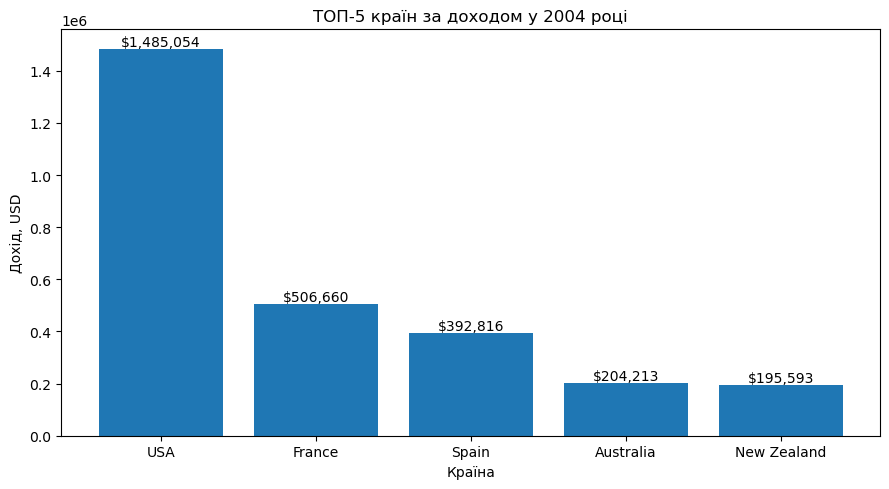

In [36]:
# Етап Load 3.2: будуємо ТОП-5 країн за доходом

print("Візуалізація: ТОП-5 країн за доходом")

# Створюємо область для графіка
plt.figure(figsize=(9, 5))

# Будуємо стовпчикову діаграму
bars = plt.bar(
    country_analysis_df["country"],
    country_analysis_df["total_revenue"]
)

# Додаємо назву та підписи осей
plt.title("ТОП-5 країн за доходом у 2004 році")
plt.xlabel("Країна")
plt.ylabel("Дохід, USD")

# Додаємо значення доходу над кожним стовпчиком
for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom"
    )

# Робимо графік компактним
plt.tight_layout()

# Виводимо графік
plt.show()

**2.Рie chart з відсотковим розподілом доходу в USD по продуктових лінійках**

Візуалізація: розподіл доходу по продуктових лініях


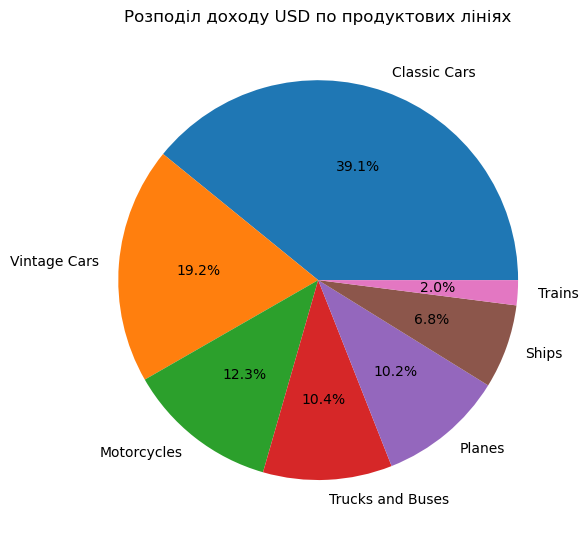

In [38]:
# Етап Load 3.2: будуємо розподіл доходу по продуктових лініях

print("Візуалізація: розподіл доходу по продуктових лініях")

# Створюємо область для графіка
plt.figure(figsize=(6, 6))

# Будуємо кругову діаграму
plt.pie(
    product_line_analysis_df["total_revenue"],
    labels=product_line_analysis_df["productLine"],
    autopct="%1.1f%%"
)

# Додаємо назву графіка
plt.title("Розподіл доходу USD по продуктових лініях")

# Робимо графік компактним
plt.tight_layout()

# Виводимо графік
plt.show()

In [39]:
# Фінальна функція ETL за прикладом з лекції

def run_classicmodels_etl(engine, excel_filename="classicmodels_etl_report.xlsx"):
    """
    Виконує повний ETL-процес для аналізу продажів ClassicModels за 2004 рік
    """

    print("Запуск ETL-пайплайну...")

    try:
        # EXTRACT: витягуємо дані з бази даних
        print("\n1. EXTRACT - витягування даних")

        # Дані про виконані замовлення за 2004 рік
        sales_df = pd.read_sql("""
        SELECT
            o.orderNumber,
            o.orderDate,
            o.status,
            c.customerNumber,
            c.customerName,
            c.country,
            od.productCode,
            p.productName,
            p.productLine,
            od.quantityOrdered,
            od.priceEach,
            p.buyPrice
        FROM orders AS o
        JOIN orderdetails AS od
            ON o.orderNumber = od.orderNumber
        JOIN products AS p
            ON od.productCode = p.productCode
        JOIN customers AS c
            ON o.customerNumber = c.customerNumber
        WHERE YEAR(o.orderDate) = 2004
          AND o.status = 'Shipped';
        """, engine, parse_dates=["orderDate"])

        # Дані про продукти
        products_df = pd.read_sql("""
        SELECT
            productCode,
            productName,
            productLine,
            buyPrice,
            MSRP
        FROM products;
        """, engine)

        # Беремо курси валют за останню доступну дату
        rates_df = pd.read_sql("""
        SELECT *
        FROM currency_rates
        WHERE rate_date = (
            SELECT MAX(rate_date)
            FROM currency_rates
        );
        """, engine)

        print(f"Продажі: {len(sales_df)} записів")
        print(f"Продукти: {len(products_df)} записів")
        print(f"Курси валют: {len(rates_df)} записів")


        # TRANSFORM: обробляємо дані
        print("\n2. TRANSFORM - обробка даних")

        # Отримуємо курс EUR
        eur_rate = rates_df.loc[
            rates_df["currency_code"] == "EUR",
            "rate_to_usd"
        ].iloc[0]

        print(f"Курс EUR: {eur_rate}")

        # Розраховуємо суму товарної позиції
        sales_df["total_amount"] = (
            sales_df["priceEach"] *
            sales_df["quantityOrdered"]
        )

        # Розраховуємо прибуток з одного товару
        sales_df["profit_per_item"] = (
            sales_df["priceEach"] -
            sales_df["buyPrice"]
        )

        # Розраховуємо загальний прибуток
        sales_df["total_profit"] = (
            sales_df["profit_per_item"] *
            sales_df["quantityOrdered"]
        )

        # Розраховуємо суму в EUR згідно з умовою завдання
        sales_df["total_amount_eur"] = (
            sales_df["total_amount"] / eur_rate
        )

        # Створюємо ТОП-5 країн за доходом
        countries_df = (
            sales_df
            .groupby("country", as_index=False)
            .agg(
                unique_orders=("orderNumber", "nunique"),
                total_revenue=("total_amount", "sum"),
                total_profit=("total_profit", "sum"),
                quantity_sold=("quantityOrdered", "sum")
            )
        )

        # Розраховуємо маржу по країнах
        countries_df["profit_margin_pct"] = (
            countries_df["total_profit"] /
            countries_df["total_revenue"] * 100
        )

        # Сортуємо та залишаємо ТОП-5
        countries_df = (
            countries_df
            .sort_values("total_revenue", ascending=False)
            .head(5)
            .reset_index(drop=True)
        )

        # Створюємо таблицю по продуктових лініях
        product_lines_df = (
            sales_df
            .groupby("productLine", as_index=False)
            .agg(
                unique_orders=("orderNumber", "nunique"),
                total_revenue=("total_amount", "sum"),
                total_profit=("total_profit", "sum"),
                quantity_sold=("quantityOrdered", "sum")
            )
        )

        # Розраховуємо маржу по продуктових лініях
        product_lines_df["profit_margin_pct"] = (
            product_lines_df["total_profit"] /
            product_lines_df["total_revenue"] * 100
        )

        # Сортуємо за доходом
        product_lines_df = (
            product_lines_df
            .sort_values("total_revenue", ascending=False)
            .reset_index(drop=True)
        )

        # Округлюємо показники
        for df in [countries_df, product_lines_df]:
            df["total_revenue"] = df["total_revenue"].round(2)
            df["total_profit"] = df["total_profit"].round(2)
            df["profit_margin_pct"] = df["profit_margin_pct"].round(2)

        # Розраховуємо Executive Summary
        total_revenue_usd = sales_df["total_amount"].sum()
        total_revenue_eur = sales_df["total_amount_eur"].sum()
        total_profit_usd = sales_df["total_profit"].sum()

        profit_margin_pct = (
            total_profit_usd /
            total_revenue_usd * 100
        )

        average_order_value = sales_df["total_amount"].mean()

        executive_summary_df = pd.DataFrame({
            "total_revenue_usd": [round(total_revenue_usd, 2)],
            "total_revenue_eur": [round(total_revenue_eur, 2)],
            "total_profit_usd": [round(total_profit_usd, 2)],
            "profit_margin_pct": [round(profit_margin_pct, 2)],
            "average_order_value": [round(average_order_value, 2)],
            "unique_orders": [sales_df["orderNumber"].nunique()],
            "unique_customers": [sales_df["customerName"].nunique()],
            "min_date": [sales_df["orderDate"].min()],
            "max_date": [sales_df["orderDate"].max()],
            "top_country": [countries_df.iloc[0]["country"]],
            "top_product_line": [product_lines_df.iloc[0]["productLine"]]
        })

        print("Transform завершено")
        print(f"Маржа прибутку: {profit_margin_pct:.2f} %")


        # LOAD: зберігаємо результати
        print("\n3. LOAD - збереження результатів")

        # Готуємо Summary у форматі "Показник - Значення"
        summary_for_excel = (
            executive_summary_df
            .T
            .reset_index()
        )

        summary_for_excel.columns = ["Показник", "Значення"]

        # Створюємо Excel-файл з трьома вкладками
        with pd.ExcelWriter(
            excel_filename,
            engine="openpyxl"
        ) as writer:

            summary_for_excel.to_excel(
                writer,
                sheet_name="Summary",
                index=False
            )

            countries_df.to_excel(
                writer,
                sheet_name="Top_Countries",
                index=False
            )

            product_lines_df.to_excel(
                writer,
                sheet_name="Product_Lines",
                index=False
            )

        print(f"Excel-файл створено: {excel_filename}")
        print("Файл існує:", os.path.exists(excel_filename))


        # Перевіряємо результат
        print("\n4. ПЕРЕВІРКА")

        print(
            "Дати тільки за 2004 рік:",
            sales_df["orderDate"].dt.year.eq(2004).all()
        )

        print(
            "Маржа в межах 0-50%:",
            0 <= profit_margin_pct <= 50
        )

        print("ТОП країна:", countries_df.iloc[0]["country"])

        print(
            "ТОП продуктова лінія:",
            product_lines_df.iloc[0]["productLine"]
        )

        excel_check = pd.ExcelFile(excel_filename)

        print(
            "Вкладки Excel:",
            excel_check.sheet_names
        )


        # Візуалізація ТОП-5 країн
        print("\n5. ВІЗУАЛІЗАЦІЯ")

        plt.figure(figsize=(9, 5))

        bars = plt.bar(
            countries_df["country"],
            countries_df["total_revenue"]
        )

        plt.title("ТОП-5 країн за доходом у 2004 році")
        plt.xlabel("Країна")
        plt.ylabel("Дохід, USD")

        for bar in bars:
            value = bar.get_height()

            plt.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"${value:,.0f}",
                ha="center",
                va="bottom"
            )

        plt.tight_layout()
        plt.show()


        # Візуалізація доходу по продуктових лініях
        plt.figure(figsize=(8, 8))

        plt.pie(
            product_lines_df["total_revenue"],
            labels=product_lines_df["productLine"],
            autopct="%1.1f%%"
        )

        plt.title(
            "Розподіл доходу USD по продуктових лініях"
        )

        plt.tight_layout()
        plt.show()


        print("\nETL-пайплайн завершено успішно!")

        # Повертаємо основні результати
        return {
            "sales": sales_df,
            "products": products_df,
            "currency_rates": rates_df,
            "top_countries": countries_df,
            "product_lines": product_lines_df,
            "summary": executive_summary_df
        }

    except Exception as e:
        print(f"Помилка в ETL-пайплайні: {e}")
        return None

Запуск ETL-пайплайну...

1. EXTRACT - витягування даних
Продажі: 1353 записів
Продукти: 110 записів
Курси валют: 6 записів

2. TRANSFORM - обробка даних
Курс EUR: 0.879
Transform завершено
Маржа прибутку: 40.08 %

3. LOAD - збереження результатів
Excel-файл створено: classicmodels_etl_report.xlsx
Файл існує: True

4. ПЕРЕВІРКА
Дати тільки за 2004 рік: True
Маржа в межах 0-50%: True
ТОП країна: USA
ТОП продуктова лінія: Classic Cars
Вкладки Excel: ['Summary', 'Top_Countries', 'Product_Lines']

5. ВІЗУАЛІЗАЦІЯ


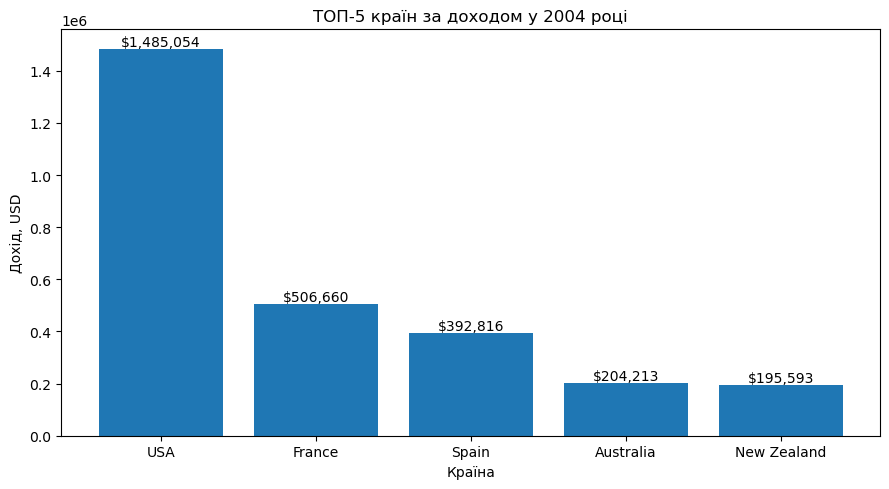

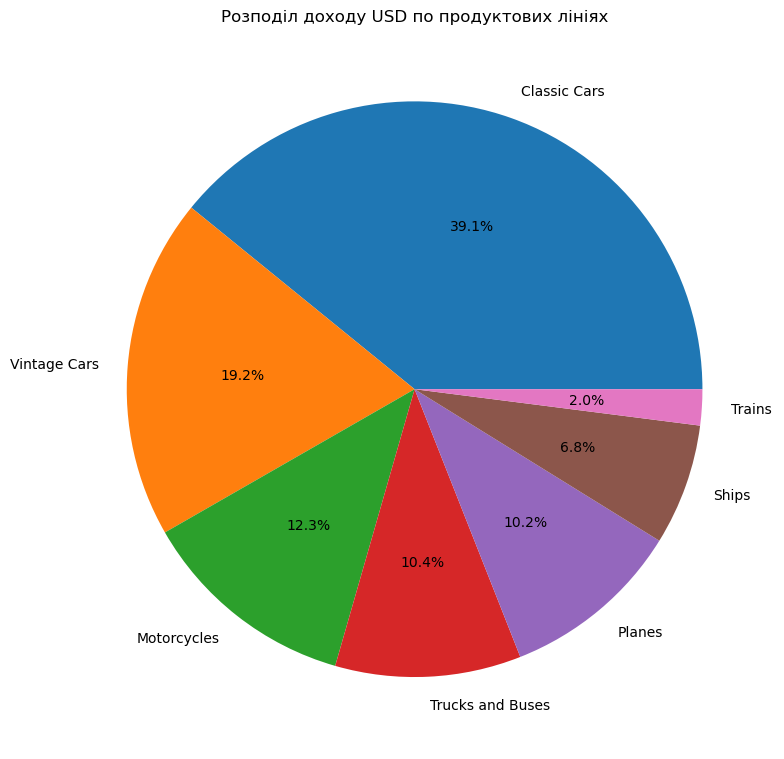


ETL-пайплайн завершено успішно!


In [40]:
# Запускаємо фінальний ETL-пайплайн

result = run_classicmodels_etl(engine)